In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install datasets -q

from datasets import load_dataset
import os

dataset_path = "/content/drive/MyDrive/EuroSAT"
os.makedirs(dataset_path, exist_ok=True)

# Load EuroSAT dataset
dataset = load_dataset("blanchon/EuroSAT")

print("Dataset downloaded successfully!")
print(dataset)

Dataset downloaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})


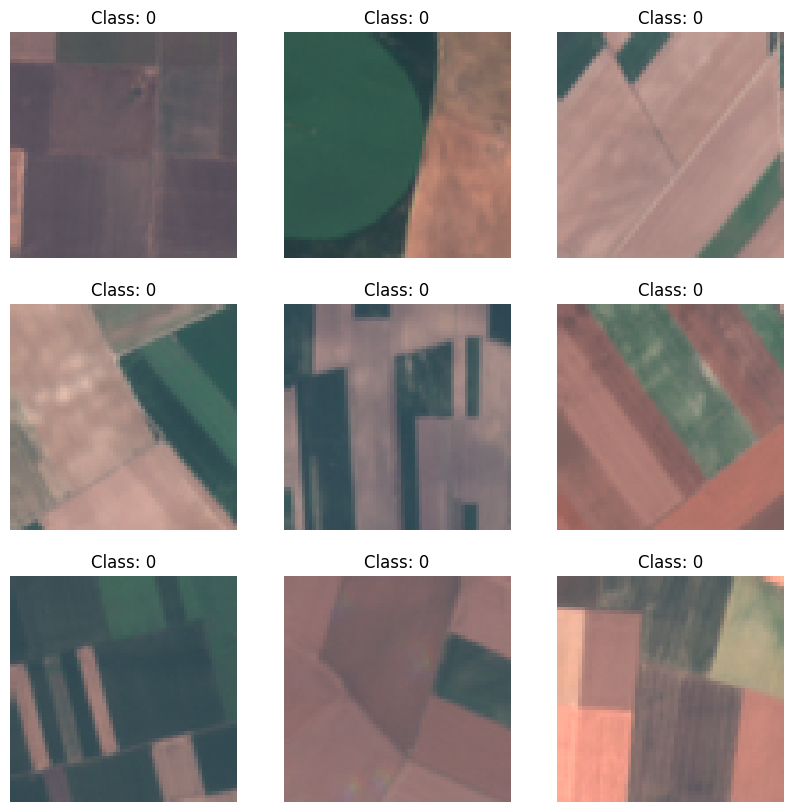

In [ ]:
import matplotlib.pyplot as plt

# Show 9 random satellite images
plt.figure(figsize=(10,10))

for i in range(9):
    image = dataset["train"][i]["image"]
    label = dataset["train"][i]["label"]

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(f"Class: {label}")
    plt.axis("off")

plt.show()

In [ ]:
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def preprocess(example):
    image = example["image"]

    # Convert list → numpy array → PIL image
    if isinstance(image, list):
        image = np.array(image, dtype=np.uint8)

    image = Image.fromarray(image)

    return {
        "pixel_values": transform(image),
        "labels": example["label"]
    }

dataset = dataset.with_transform(preprocess)

split_dataset = dataset.train_test_split(test_size=0.2)

train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

print("Preprocessing fixed ✅")

AttributeError: 'DatasetDict' object has no attribute 'train_test_split'

# OLD PREPROCESSING CODE - DO NOT RUN
# This creates 3-channel RGB images and does not match the 13-channel model.

In [ ]:
from datasets import load_dataset

# Reload EuroSAT fresh
dataset = load_dataset("blanchon/EuroSAT")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})


In [ ]:
from datasets import load_dataset

# Reload EuroSAT fresh
dataset = load_dataset("blanchon/EuroSAT")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def preprocess(example):
    image = example["image"]

    # Convert list to image
    if isinstance(image, list):
        image = np.array(image, dtype=np.uint8)

    image = Image.fromarray(image)

    return {
        "pixel_values": transform(image),
        "labels": example["label"]
    }

train_dataset = dataset["train"].with_transform(preprocess)
test_dataset = dataset["test"].with_transform(preprocess)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

print("Step 8 fixed ✅")

Step 8 fixed ✅


In [ ]:
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader

# Reload dataset with proper image decoding
dataset = load_dataset("blanchon/EuroSAT")

# Image transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def preprocess(example):
    return {
        "pixel_values": transform(example["image"].convert("RGB")),
        "labels": example["label"]
    }

train_dataset = dataset["train"].with_transform(preprocess)
test_dataset = dataset["test"].with_transform(preprocess)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

print("Ready ✅")

Ready ✅


In [ ]:
from datasets import load_dataset, Image
from torchvision import transforms
from torch.utils.data import DataLoader

# Reload dataset
dataset = load_dataset("blanchon/EuroSAT")

# Force image decoding
dataset = dataset.cast_column("image", Image())

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def preprocess(example):
    return {
        "pixel_values": transform(example["image"]),
        "labels": example["label"]
    }

train_dataset = dataset["train"].with_transform(preprocess)
test_dataset = dataset["test"].with_transform(preprocess)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

print("Dataset fixed ✅")

Dataset fixed ✅


In [ ]:
!pip install torchgeo -q

In [ ]:
from torchgeo.datasets import EuroSAT

dataset = EuroSAT(root="data", download=True)

print(dataset)

EuroSAT Dataset
    type: NonGeoDataset
    size: 16200


In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Apply transform
dataset.transforms = transform

# Create loader
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("DataLoader ready ✅")

DataLoader ready ✅


In [ ]:
batch = next(iter(train_loader))

print(batch.keys())

dict_keys(['image', 'label'])


In [ ]:
image = batch["image"]
label = batch["label"]

print(type(image))
print(type(label))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [ ]:
batch = next(iter(train_loader))

image = batch["image"]
label = batch["label"]

print(image.shape)
print(label.shape)

torch.Size([32, 13, 64, 64])
torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SatelliteCNN(nn.Module):
    def __init__(self):
        super(SatelliteCNN, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(13, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)


model = SatelliteCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model created ✅")
print("Using:", device)

Model created ✅
Using: cuda


In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {total_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

print("Training complete ✅")

Epoch 1/10 Loss: 226.7488 Accuracy: 84.86%
Epoch 2/10 Loss: 223.2614 Accuracy: 85.16%
Epoch 3/10 Loss: 195.6269 Accuracy: 86.99%
Epoch 4/10 Loss: 166.0162 Accuracy: 88.81%
Epoch 5/10 Loss: 218.4944 Accuracy: 86.10%
Epoch 6/10 Loss: 190.2219 Accuracy: 88.20%
Epoch 7/10 Loss: 169.3371 Accuracy: 88.56%
Epoch 8/10 Loss: 177.0827 Accuracy: 88.67%
Epoch 9/10 Loss: 149.6994 Accuracy: 90.34%
Epoch 10/10 Loss: 139.5158 Accuracy: 91.00%
Training complete ✅


In [ ]:
from torch.utils.data import DataLoader

# Use the same EuroSAT dataset for testing
test_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False
)

print("Test loader created ✅")

Test loader created ✅


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 92.13%


In [ ]:
classes = [
    "Annual Crop",
    "Forest",
    "Herbaceous Vegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "Permanent Crop",
    "Residential",
    "River",
    "Sea/Lake"
]

model.eval()

sample = next(iter(train_loader))

image = sample["image"][0].to(device)
true_label = sample["label"][0].item()

with torch.no_grad():
    output = model(image.unsqueeze(0))
    prediction = torch.argmax(output, dim=1).item()

print("Actual:", classes[true_label])
print("Predicted:", classes[prediction])

Actual: Herbaceous Vegetation
Predicted: Herbaceous Vegetation


In [ ]:
forest_class = 1  # EuroSAT label for Forest

def detect_forest(image):
    model.eval()

    with torch.no_grad():
        image = image.unsqueeze(0).to(device)

        output = model(image)

        prediction = torch.argmax(output, dim=1).item()

    if prediction == forest_class:
        return "Forest 🌲"
    else:
        return "Non-Forest 🌍"


# Test on one image
sample = next(iter(train_loader))

image = sample["image"][0]

result = detect_forest(image)

print("AI Prediction:", result)

AI Prediction: Forest 🌲


In [ ]:
forest_count = 0
total_images = 0

model.eval()

with torch.no_grad():
    for batch in train_loader:
        images = batch["image"].to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        forest_count += (predictions == 1).sum().item()
        total_images += len(predictions)

forest_percentage = (forest_count / total_images) * 100

print(f"Forest Coverage Estimate: {forest_percentage:.2f}%")

Forest Coverage Estimate: 10.22%


In [ ]:
import torch

torch.save(model.state_dict(), "satellite_forest_classifier.pth")

print("Model saved ✅")

Model saved ✅


In [ ]:
classes = [
    "Annual Crop",
    "Forest",
    "Herbaceous Vegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "Permanent Crop",
    "Residential",
    "River",
    "Sea/Lake"
]

class_counts = {name: 0 for name in classes}

model.eval()

with torch.no_grad():
    for batch in train_loader:
        images = batch["image"].to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        for pred in predictions:
            class_counts[classes[pred.item()]] += 1

print(class_counts)

{'Annual Crop': 1415, 'Forest': 1631, 'Herbaceous Vegetation': 2025, 'Highway': 1222, 'Industrial': 1689, 'Pasture': 1177, 'Permanent Crop': 1915, 'Residential': 1793, 'River': 1497, 'Sea/Lake': 1836}


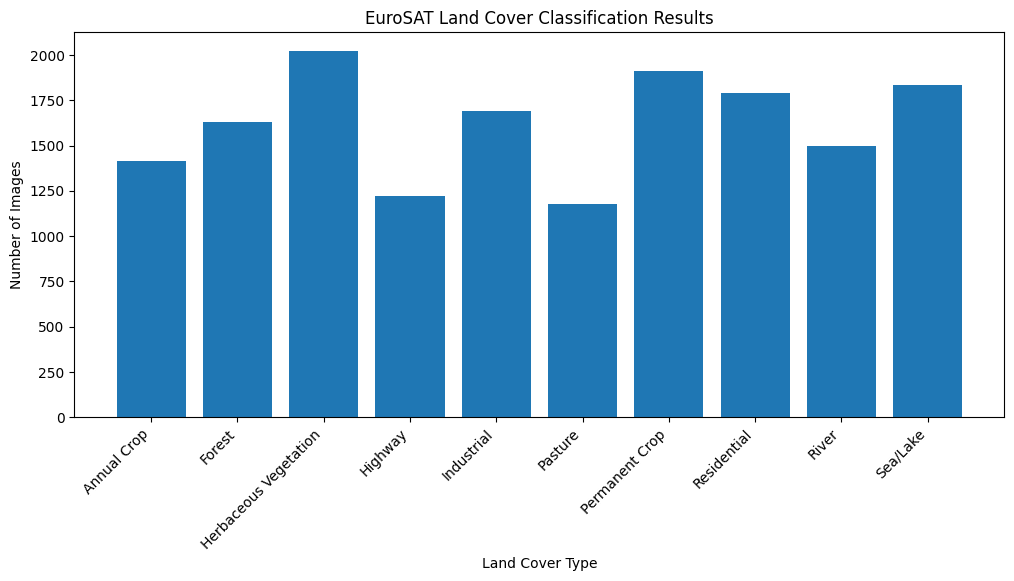

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Land Cover Type")
plt.ylabel("Number of Images")
plt.title("EuroSAT Land Cover Classification Results")

plt.show()

In [ ]:
# Original forest count
original_forest = class_counts["Forest"]

# Simulate 20% forest loss
loss_percentage = 20

lost_forest = int(original_forest * (loss_percentage / 100))

new_forest = original_forest - lost_forest

actual_loss = (
    (original_forest - new_forest)
    / original_forest
) * 100

print("Original Forest Images:", original_forest)
print("Forest Lost:", lost_forest)
print("Remaining Forest Images:", new_forest)
print(f"Deforestation Rate: {actual_loss:.2f}%")

Original Forest Images: 1631
Forest Lost: 326
Remaining Forest Images: 1305
Deforestation Rate: 19.99%


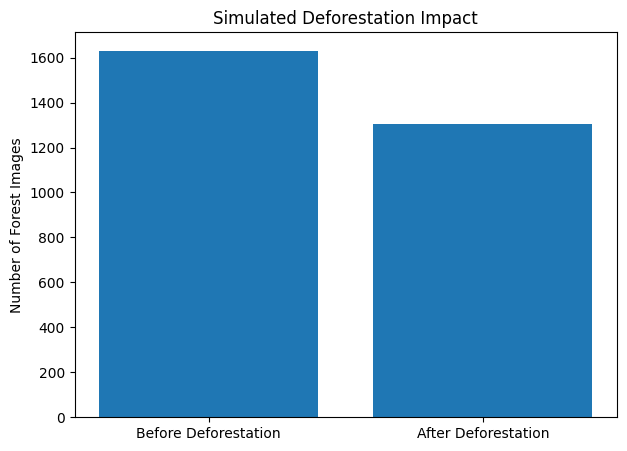

In [ ]:
import matplotlib.pyplot as plt

labels = ["Before Deforestation", "After Deforestation"]
values = [original_forest, new_forest]

plt.figure(figsize=(7,5))

plt.bar(labels, values)

plt.ylabel("Number of Forest Images")
plt.title("Simulated Deforestation Impact")

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import torch

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions collected ✅")

Predictions collected ✅


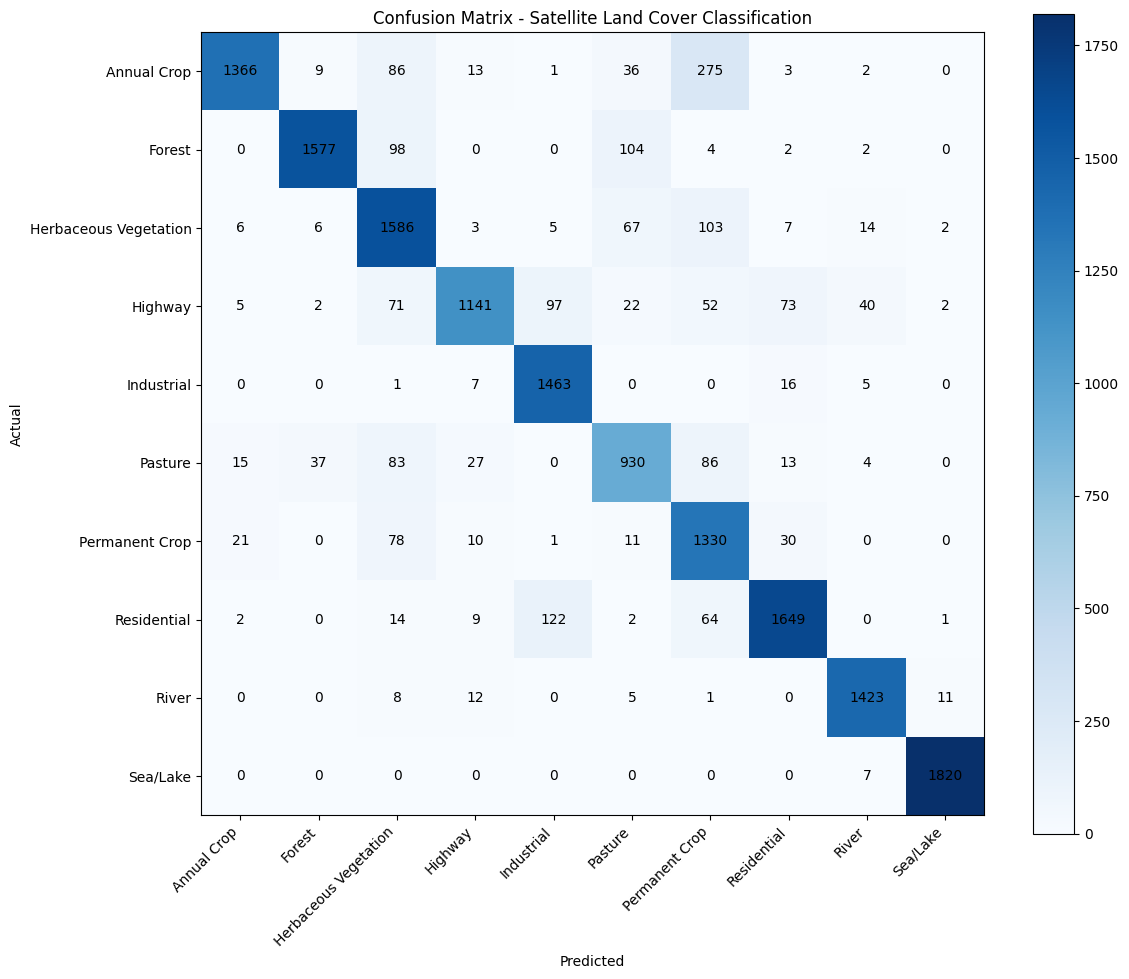

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(12,10))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Satellite Land Cover Classification")

# Put numbers inside boxes
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

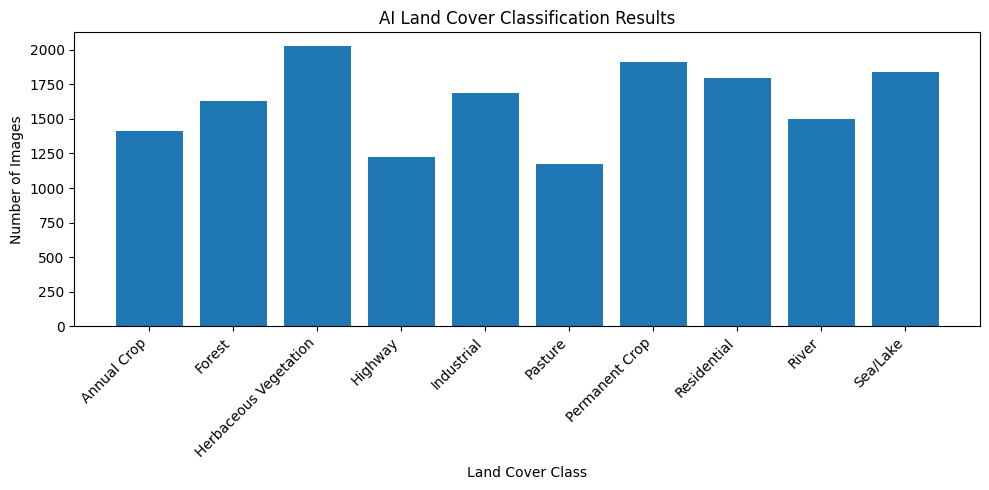

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Land Cover Class")
plt.ylabel("Number of Images")
plt.title("AI Land Cover Classification Results")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download("satellite_forest_classifier.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# CNN model
class SatelliteCNN(nn.Module):
    def __init__(self):
        super(SatelliteCNN, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

# Create model
model = SatelliteCNN().to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("CNN model created successfully ✅")

Using: cuda
CNN model created successfully ✅


In [ ]:
import os
print(os.path.getsize("satellite_forest_classifier.pth"))

8789253


In [ ]:
model.load_state_dict(torch.load("satellite_forest_classifier.pth"))
model.eval()

print("Model loaded ✅")

Model loaded ✅
